# **SHAP Interpretability on REAL Data (BizFlow Engine v1.0)**
**Project:** BizFlow360 — ML Early Warning System for Kenyan MSMEs
**Author:** Edusei Mikel Lisamba (Team Lead & ML Integration)

**What this notebook does:** Loads the champion engine (`bizflow_engine_v1.0.joblib`), recreates the exact test set from the real KNBS data, and uses SHAP to generate the two transparency charts for Chapter 5: the Global Feature Importance plot and the Single-MSME Waterfall explanation.

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# base_dir = ml_models/ (one level up from notebooks_2/)
base_dir = os.path.abspath('..')

# Correct paths to the on_real_data subfolders
data_path   = os.path.join(base_dir, 'data', 'unified_msme_modeling_data.csv')
model_path  = os.path.join(base_dir, 'models', 'trained', 'on_real_data', 'bizflow_engine_v1.0.joblib')
scaler_path = os.path.join(base_dir, 'models', 'preprocessing', 'on_real_data', 'scaler.joblib')
county_path = os.path.join(base_dir, 'models', 'preprocessing', 'on_real_data', 'le_county.joblib')
sector_path = os.path.join(base_dir, 'models', 'preprocessing', 'on_real_data', 'le_sector.joblib')
metrics_dir = os.path.join(base_dir, 'models', 'metrics', 'on_real_data')

print(f"Base directory: {base_dir}")

Base directory: /home/mikel/BizFlow360/ml_models


# 1. Load the Dataset, Champion Engine and Preprocessors
**What this cell does:** Loads the unified real KNBS dataset, the LightGBM champion engine, and the scaler + label encoders that were fitted on the real data.

In [2]:
df = pd.read_csv(data_path)

model     = joblib.load(model_path)
scaler    = joblib.load(scaler_path)
le_county = joblib.load(county_path)
le_sector = joblib.load(sector_path)

print(f"✅ Loaded dataset: {df.shape}")
print(f"✅ Champion engine: {type(model).__name__}")

✅ Loaded dataset: (15814, 23)
✅ Champion engine: LGBMClassifier


# 2. Recreate the Exact Test Set
**What this cell does:** Applies the exact same cleaning (KNBS placeholders → median), encoding, 80/20 split (random_state=42) and scaling used during training, so the SHAP explanations are computed on the exact same unseen test data the metrics were scored on.

In [3]:
# 1. Safety clean KNBS placeholders (must match training exactly)
knbs_placeholders = [-19.11, -19.305, -2.4696, -2.4948, -20.58, -73.5, -74.25, -3.528, -8.82]
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].replace(knbs_placeholders, np.nan)
    df[col] = df[col].fillna(df[col].median())

# 2. Encode county and sector using the saved encoders
df['county_encoded'] = le_county.transform(df['county'])
df['sector_encoded'] = le_sector.transform(df['sector'])

# 3. The exact 22 features used in training
features = [
    'county_encoded', 'sector_encoded', 'male_working_owners', 'female_working_owners',
    'total_monthly_expenses', 'monthly_rent_expense', 'monthly_electricity_expense',
    'monthly_credit_expense', 'monthly_social_responsibility_expense',
    'revenue_last_month', 'normal_monthly_revenue', 'net_income_last_month',
    'stock_value_beginning', 'stock_value_end', 'total_turnover_2015',
    'net_income_margin', 'revenue_change_ratio', 'business_closed',
    'number_closed_establishments', 'revenue_decline', 'zero_or_missing_net_income', 'low_revenue'
]

X = df[features]
y = df['distress_label']

# 4. Recreate the exact same split and scale the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Test set recreated: {X_test_scaled.shape}")

✅ Test set recreated: (3163, 22)


# 3. Calculate SHAP Values
**What this cell does:** Builds a SHAP TreeExplainer for the champion engine and calculates the contribution of every feature for every business in the test set. It safely handles LightGBM's output format (which can return a list of two arrays for binary classification).

In [4]:
print("Calculating SHAP values on the test set... (may take a minute)")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# LightGBM may return [class_0, class_1]; we want the distressed class (1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Same handling for the base (expected) value
base_value = explainer.expected_value
if isinstance(base_value, (list, tuple)):
    base_value = base_value[1]

print(f"✅ SHAP values computed | Base value: {base_value:.4f}")

Calculating SHAP values on the test set... (may take a minute)
✅ SHAP values computed | Base value: -0.1389


/home/mikel/BizFlow360/venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


# 4. Global Feature Importance (Chapter 5 Chart #1)
**What this cell does:** Ranks all 22 features by their average absolute SHAP impact, showing which financial factors drive distress predictions across ALL Kenyan MSMEs. The chart is saved to `metrics/on_real_data/`.

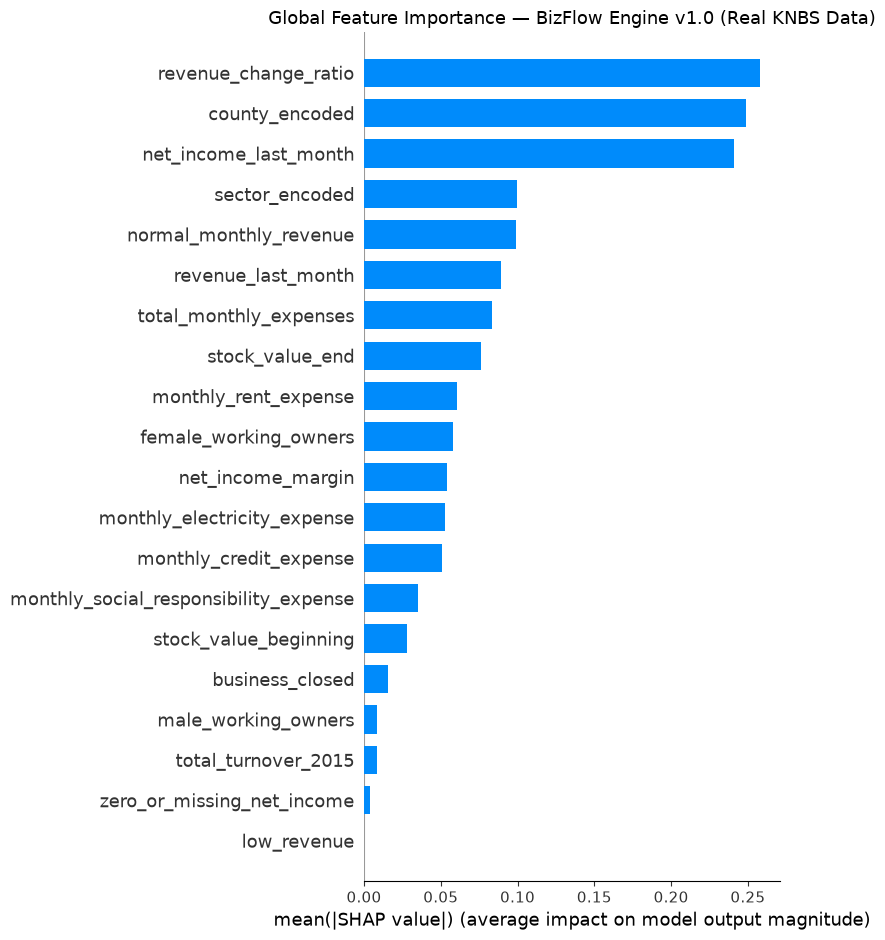

✅ Saved: /home/mikel/BizFlow360/ml_models/models/metrics/on_real_data/real_shap_feature_importance.png


In [5]:
os.makedirs(metrics_dir, exist_ok=True)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=features, plot_type="bar", show=False)
plt.title("Global Feature Importance — BizFlow Engine v1.0 (Real KNBS Data)", fontsize=13)
plt.tight_layout()

importance_path = os.path.join(metrics_dir, 'real_shap_feature_importance.png')
plt.savefig(importance_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {importance_path}")

# 5. Explaining a Single Distressed MSME (Chapter 5 Chart #2)
**What this cell does:** Picks a business that is truly distressed AND correctly flagged by the engine (probability > 60%), then generates a Waterfall plot showing the exact "Key Risk Factors" pushing that specific business into the red. Saved to `metrics/on_real_data/`.

Explaining test sample #12 | True: Distressed | Engine probability: 80.80%


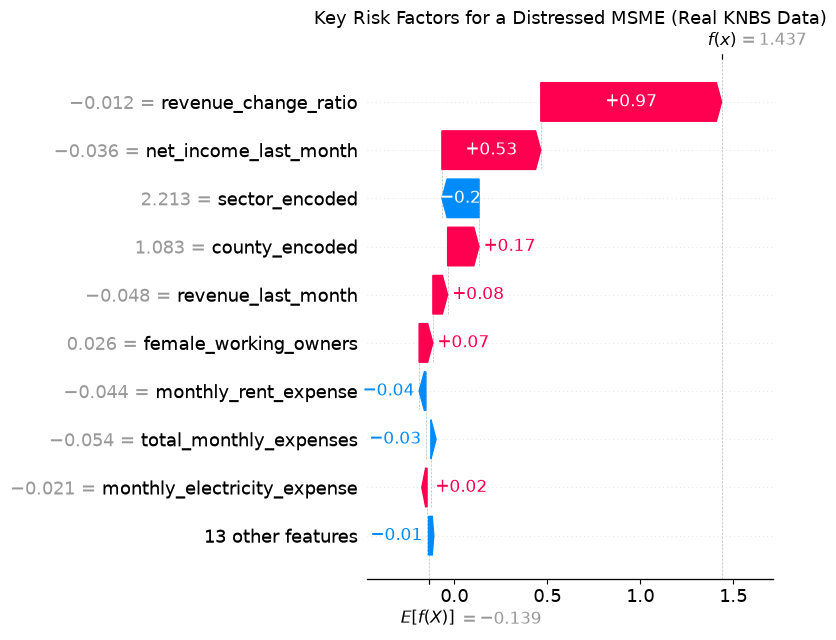

✅ Saved: /home/mikel/BizFlow360/ml_models/models/metrics/on_real_data/real_shap_single_prediction_example.png


In [7]:
# Find a truly distressed business the engine correctly flagged
y_prob = model.predict_proba(X_test_scaled)[:, 1]
good_examples = np.where((y_test.values == 1) & (y_prob > 0.6))[0]

sample_idx = good_examples[0] if len(good_examples) > 0 else np.where(y_test.values == 1)[0][0]

print(f"Explaining test sample #{sample_idx} | True: Distressed | Engine probability: {y_prob[sample_idx]:.2%}")

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_value,
    data=X_test_scaled[sample_idx],
    feature_names=features
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(explanation, show=False)
plt.title("Key Risk Factors for a Distressed MSME (Real KNBS Data)", fontsize=13)
plt.tight_layout()

waterfall_path = os.path.join(metrics_dir, 'real_shap_single_prediction_example.png')
plt.savefig(waterfall_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {waterfall_path}")

# 6. Conclusion & Next Steps
The ML pipeline is now 100% complete on REAL data with full transparency. Commit this milestone:

```bash
git add .
git commit -m "feat: completed real-data SHAP interpretability for bizflow_engine_v1.0"
git push
```

---

Run all cells in order. When Cell 12 finishes, you will have both transparency charts saved in `metrics/on_real_data/`, ready for Chapter 5 and for the Streamlit app. Let me know once it runs clean!